In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
import os

from statsmodels.miscmodels.ordinal_model import OrderedModel

%load_ext autoreload
%autoreload 2

import utils.columns as cols
import utils.transform as transform
import utils.univariate as univar
import utils.bivariate as bivar
import utils.ordinal_regression as ordinal
import utils.experiment as experiment


# Read Preprocessed Mental, Social, and Green Space Datasets

In [2]:
# Define the base directory
BASE_PATH = '../final_data/processed'

# Load datasets using a dictionary comprehension
files = {
    'mental': f'{BASE_PATH}/medical/basis/mental_health_dataset_b.xlsx',
    'social': f'{BASE_PATH}/medical/basis/social_factors_dataset_b.xlsx',
    'green': f'{BASE_PATH}/environmental/basis/green_space_dataset_b.xlsx'
}

datasets = {name: pd.read_excel(path, index_col=0) for name, path in files.items()}

# Combine all datasets at once along the index (columns/horizontal alignment)
data_complete = pd.concat(datasets.values(), axis=1, join='outer')


In [3]:
data_complete = transform.rename_columns(data_complete)

# Age grouping

In [4]:
data_complete['Age_group'] = transform.categorize(
    data_complete, 'Age', bins=[0,40,53,65,np.inf], right=False, labels=["[18, 40)","[40, 53)","[53, 65)","[65, 81)"]
)

# Outcome Direction Map

In [5]:
outcome_direction_map = {
    "CES-D Ordinal":  {"direction": "higher_is_worse", "label": "more severe depressive symptoms"},
    "GAD-7 Ordinal":  {"direction": "higher_is_worse", "label": "more severe anxiety symptoms"},
    "SWLS Ordinal":   {"direction": "higher_is_better", "label": "better life satisfaction"},
}

# Ordinal Model: Mental Health Scores across Green Exposures

## NDVI – continuous

In [8]:
data = data_complete.copy()

outcomes = cols.mental_ordinal
predictors = cols.ndvi

results_df, model_store = experiment.run_ordinal_grid(
    data                  = data,
    outcomes              = outcomes,
    predictors            = predictors,
    predictor_type        = "continuous",
    scale_predictor       = 0.1,
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Age", "Sex", "Socioeconomic Status (Tiers)"],
)

display(results_df)

  [1/12] CES-D Ordinal × NDVI (100m Buffer)
  [2/12] CES-D Ordinal × NDVI (200m Buffer)
  [3/12] CES-D Ordinal × NDVI (500m Buffer)
  [4/12] CES-D Ordinal × NDVI (1000m Buffer)
  [5/12] GAD-7 Ordinal × NDVI (100m Buffer)
  [6/12] GAD-7 Ordinal × NDVI (200m Buffer)
  [7/12] GAD-7 Ordinal × NDVI (500m Buffer)
  [8/12] GAD-7 Ordinal × NDVI (1000m Buffer)
  [9/12] SWLS Ordinal × NDVI (100m Buffer)
  [10/12] SWLS Ordinal × NDVI (200m Buffer)
  [11/12] SWLS Ordinal × NDVI (500m Buffer)
  [12/12] SWLS Ordinal × NDVI (1000m Buffer)

  Grid complete: 12/12 models fitted.


,outcome,predictor,predictor_type,n,outcome_direction,scale_predictor,reference_level,level,beta,OR,CI_lower,CI_upper,OR_95CI,p_value,p_value_fmt,pct_change_odds,interpretation,covariates
0,CES-D Ordinal,NDVI (100m Buffer),continuous,9117,higher_is_worse,0.1,None,NDVI (100m Buffer),-0.208,0.812,0.737,0.895,"0.812 (0.737, 0.895)",2.497027e-05,<0.001,18.8,18.8% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)"
1,CES-D Ordinal,NDVI (200m Buffer),continuous,9117,higher_is_worse,0.1,None,NDVI (200m Buffer),-0.250,0.779,0.703,0.863,"0.779 (0.703, 0.863)",1.716493e-06,<0.001,22.1,22.1% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)"
2,CES-D Ordinal,NDVI (500m Buffer),continuous,9117,higher_is_worse,0.1,None,NDVI (500m Buffer),-0.216,0.806,0.725,0.896,"0.806 (0.725, 0.896)",6.197057e-05,<0.001,19.4,19.4% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)"
3,CES-D Ordinal,NDVI (1000m Buffer),continuous,9117,higher_is_worse,0.1,None,NDVI (1000m Buffer),-0.201,0.818,0.732,0.914,"0.818 (0.732, 0.914)",4.044048e-04,<0.001,18.2,18.2% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)"
4,GAD-7 Ordinal,NDVI (100m Buffer),continuous,9278,higher_is_worse,0.1,None,NDVI (100m Buffer),-0.053,0.948,0.900,0.999,"0.948 (0.900, 0.999)",4.486416e-02,0.045,5.2,5.2% lower odds of more severe anxiety symptom...,"Age, Sex, Socioeconomic Status (Tiers)"
5,GAD-7 Ordinal,NDVI (200m Buffer),continuous,9278,higher_is_worse,0.1,None,NDVI (200m Buffer),-0.065,0.937,0.887,0.990,"0.937 (0.887, 0.990)",2.001151e-02,0.020,6.3,6.3% lower odds of more severe anxiety symptom...,"Age, Sex, Socioeconomic Status (Tiers)"
6,GAD-7 Ordinal,NDVI (500m Buffer),continuous,9278,higher_is_worse,0.1,None,NDVI (500m Buffer),-0.100,0.905,0.855,0.958,"0.905 (0.855, 0.958)",5.795962e-04,<0.001,9.5,9.5% lower odds of more severe anxiety symptom...,"Age, Sex, Socioeconomic Status (Tiers)"
7,GAD-7 Ordinal,NDVI (1000m Buffer),continuous,9278,higher_is_worse,0.1,None,NDVI (1000m Buffer),-0.096,0.909,0.856,0.965,"0.909 (0.856, 0.965)",1.902831e-03,0.002,9.1,9.1% lower odds of more severe anxiety symptom...,"Age, Sex, Socioeconomic Status (Tiers)"
8,SWLS Ordinal,NDVI (100m Buffer),continuous,9297,higher_is_better,0.1,None,NDVI (100m Buffer),0.153,1.166,1.115,1.219,"1.166 (1.115, 1.219)",1.523069e-11,<0.001,16.6,16.6% higher odds of better life satisfaction ...,"Age, Sex, Socioeconomic Status (Tiers)"
9,SWLS Ordinal,NDVI (200m Buffer),continuous,9297,higher_is_better,0.1,None,NDVI (200m Buffer),0.186,1.205,1.150,1.263,"1.205 (1.150, 1.263)",7.533950e-15,<0.001,20.5,20.5% higher odds of better life satisfaction ...,"Age, Sex, Socioeconomic Status (Tiers)"


## Save Linear Regression results to `ordinal_results` in `pkl` and `csv`

In [9]:
##out_path = f"outputs/ordinal/mental_ordinal/ndvi/adjusted/ordinal_results" ## ndvi | quartiles
##experiment.save_results(results_df, model_store, path=out_path)

  Saved pickle : outputs/ordinal/mental_ordinal/ndvi/adjusted/ordinal_results.pkl
  Saved CSV    : outputs/ordinal/mental_ordinal/ndvi/adjusted/ordinal_results.csv


## Land-use-based Green Space – Quartiles

In [12]:
data = data_complete.copy()

outcomes = cols.mental_ordinal
predictors = cols.greenspace_quartiles

results_df, model_store = experiment.run_ordinal_grid(
    data                  = data,
    outcomes              = outcomes,
    predictors            = predictors,
    predictor_type        = "categorical",
    reference_category    = "1.0",
    label_mapping         = {"1.0": "Q1", "2.0": "Q2", "3.0": "Q3", "4.0": "Q4"},
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Age", "Sex", "Socioeconomic Status (Tiers)"],
)

display(results_df)

  [1/12] CES-D Ordinal × Green Space Quartile (100m Buffer)
  [2/12] CES-D Ordinal × Green Space Quartile (200m Buffer)
  [3/12] CES-D Ordinal × Green Space Quartile (500m Buffer)
  [4/12] CES-D Ordinal × Green Space Quartile (1000m Buffer)
  [5/12] GAD-7 Ordinal × Green Space Quartile (100m Buffer)
  [6/12] GAD-7 Ordinal × Green Space Quartile (200m Buffer)
  [7/12] GAD-7 Ordinal × Green Space Quartile (500m Buffer)
  [8/12] GAD-7 Ordinal × Green Space Quartile (1000m Buffer)
  [9/12] SWLS Ordinal × Green Space Quartile (100m Buffer)
  [10/12] SWLS Ordinal × Green Space Quartile (200m Buffer)
  [11/12] SWLS Ordinal × Green Space Quartile (500m Buffer)
  [12/12] SWLS Ordinal × Green Space Quartile (1000m Buffer)

  Grid complete: 12/12 models fitted.


,outcome,predictor,predictor_type,n,outcome_direction,reference_category,reference_level,level,beta,OR,CI_lower,CI_upper,OR_95CI,p_value,p_value_fmt,pct_change_odds,interpretation,covariates
0,CES-D Ordinal,Green Space Quartile (100m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q2,-0.060,0.941,0.752,1.178,"0.941 (0.752, 1.178)",5.972894e-01,0.597,5.9,5.9% lower odds of more severe depressive symp...,"Age, Sex, Socioeconomic Status (Tiers)"
1,CES-D Ordinal,Green Space Quartile (100m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q3,-0.100,0.905,0.719,1.138,"0.905 (0.719, 1.138)",3.920148e-01,0.392,9.5,9.5% lower odds of more severe depressive symp...,"Age, Sex, Socioeconomic Status (Tiers)"
2,CES-D Ordinal,Green Space Quartile (100m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q4,-0.256,0.774,0.610,0.983,"0.774 (0.610, 0.983)",3.579578e-02,0.036,22.6,22.6% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)"
3,CES-D Ordinal,Green Space Quartile (200m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q2,-0.261,0.770,0.617,0.962,"0.770 (0.617, 0.962)",2.155103e-02,0.022,23.0,23.0% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)"
4,CES-D Ordinal,Green Space Quartile (200m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q3,-0.365,0.694,0.551,0.875,"0.694 (0.551, 0.875)",1.985729e-03,0.002,30.6,30.6% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)"
5,CES-D Ordinal,Green Space Quartile (200m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q4,-0.290,0.748,0.594,0.942,"0.748 (0.594, 0.942)",1.367511e-02,0.014,25.2,25.2% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)"
6,CES-D Ordinal,Green Space Quartile (500m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q2,-0.129,0.879,0.701,1.102,"0.879 (0.701, 1.102)",2.647519e-01,0.265,12.1,12.1% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)"
7,CES-D Ordinal,Green Space Quartile (500m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q3,-0.161,0.851,0.677,1.070,"0.851 (0.677, 1.070)",1.678945e-01,0.168,14.9,14.9% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)"
8,CES-D Ordinal,Green Space Quartile (500m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q4,-0.182,0.833,0.661,1.052,"0.833 (0.661, 1.052)",1.245315e-01,0.125,16.7,16.7% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)"
9,CES-D Ordinal,Green Space Quartile (1000m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q2,0.020,1.020,0.816,1.275,"1.020 (0.816, 1.275)",8.626781e-01,0.863,2.0,2.0% higher odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)"


## Save Ordered Regression results to `ordinal_results` in `pkl` and `csv`

In [13]:
##out_path = f"outputs/ordinal/mental_ordinal/quartiles/adjusted/ordinal_results" ## ndvi | quartiles
##experiment.save_results(results_df, model_store, path=out_path)

  Saved pickle : outputs/ordinal/mental_ordinal/quartiles/adjusted/ordinal_results.pkl
  Saved CSV    : outputs/ordinal/mental_ordinal/quartiles/adjusted/ordinal_results.csv


# Load Ordinal Model results from `ordinal_results.pkl`

In [ ]:
##out_path = f"outputs/ordinal/mental_ordinal/quartiles/adjusted/ordinal_results" ## ndvi | quartiles
##results_df, model_store = experiment.load_results(out_path)

# Analysis – Mental Ordinal Scores vs Green Exposures

## NDVI – Ordinal model – unadjusted

In [14]:
out_path = f"outputs/ordinal/mental_ordinal/ndvi/unadjusted/ordinal_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "predictor_type", "n", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

#results_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]
results_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T19:54:01.523477


,outcome,predictor,predictor_type,n,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
2,CES-D Ordinal,NDVI (500m Buffer),continuous,9142,0.1,-0.251,"0.778 (0.702, 0.861)",<0.001,22.2,22.2% lower odds of more severe depressive sym...,unadjusted
6,GAD-7 Ordinal,NDVI (500m Buffer),continuous,9304,0.1,-0.108,"0.897 (0.849, 0.949)",<0.001,10.3,10.3% lower odds of more severe anxiety sympto...,unadjusted
10,SWLS Ordinal,NDVI (500m Buffer),continuous,9323,0.1,0.208,"1.232 (1.174, 1.292)",<0.001,23.2,23.2% higher odds of better life satisfaction ...,unadjusted


## NDVI – Ordinal model – adjusted: Sex, Age, SES

In [15]:
out_path = f"outputs/ordinal/mental_ordinal/ndvi/adjusted/ordinal_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "predictor_type", "n", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

results_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T19:54:25.796405


,outcome,predictor,predictor_type,n,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
2,CES-D Ordinal,NDVI (500m Buffer),continuous,9117,0.1,-0.216,"0.806 (0.725, 0.896)",<0.001,19.4,19.4% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)"
6,GAD-7 Ordinal,NDVI (500m Buffer),continuous,9278,0.1,-0.100,"0.905 (0.855, 0.958)",<0.001,9.5,9.5% lower odds of more severe anxiety symptom...,"Age, Sex, Socioeconomic Status (Tiers)"
10,SWLS Ordinal,NDVI (500m Buffer),continuous,9297,0.1,0.180,"1.198 (1.141, 1.257)",<0.001,19.8,19.8% higher odds of better life satisfaction ...,"Age, Sex, Socioeconomic Status (Tiers)"


## Land-use-based Quartiles – Ordinal model – unadjusted

In [16]:
out_path = f"outputs/ordinal/mental_ordinal/quartiles/unadjusted/ordinal_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "predictor_type", "n", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

results_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T19:55:08.557124


,outcome,predictor,predictor_type,n,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
8,CES-D Ordinal,Green Space Quartile (500m Buffer),categorical,9104,Q1,Q4,-0.309,"0.734 (0.585, 0.923)",0.008,26.6,26.6% lower odds of more severe depressive sym...,unadjusted
20,GAD-7 Ordinal,Green Space Quartile (500m Buffer),categorical,9264,Q1,Q4,-0.146,"0.864 (0.764, 0.978)",0.020,13.6,13.6% lower odds of more severe anxiety sympto...,unadjusted
32,SWLS Ordinal,Green Space Quartile (500m Buffer),categorical,9283,Q1,Q4,0.497,"1.645 (1.480, 1.828)",<0.001,64.5,64.5% higher odds of better life satisfaction ...,unadjusted


## Land-use-based Quartiles – Ordinal model – adjusted: Sex, Age, SES

In [17]:
out_path = f"outputs/ordinal/mental_ordinal/quartiles/adjusted/ordinal_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "predictor_type", "n", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

results_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T19:55:47.283216


,outcome,predictor,predictor_type,n,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
8,CES-D Ordinal,Green Space Quartile (500m Buffer),categorical,9079,Q1,Q4,-0.182,"0.833 (0.661, 1.052)",0.125,16.7,16.7% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)"
20,GAD-7 Ordinal,Green Space Quartile (500m Buffer),categorical,9238,Q1,Q4,-0.099,"0.906 (0.800, 1.027)",0.122,9.4,9.4% lower odds of more severe anxiety symptom...,"Age, Sex, Socioeconomic Status (Tiers)"
32,SWLS Ordinal,Green Space Quartile (500m Buffer),categorical,9257,Q1,Q4,0.423,"1.526 (1.372, 1.697)",<0.001,52.6,52.6% higher odds of better life satisfaction ...,"Age, Sex, Socioeconomic Status (Tiers)"


# Plot FOREST – Mental Ordinal Score vs. Green Exposure Quartiles

  Loaded results saved at: 2026-07-27T19:55:08.557124


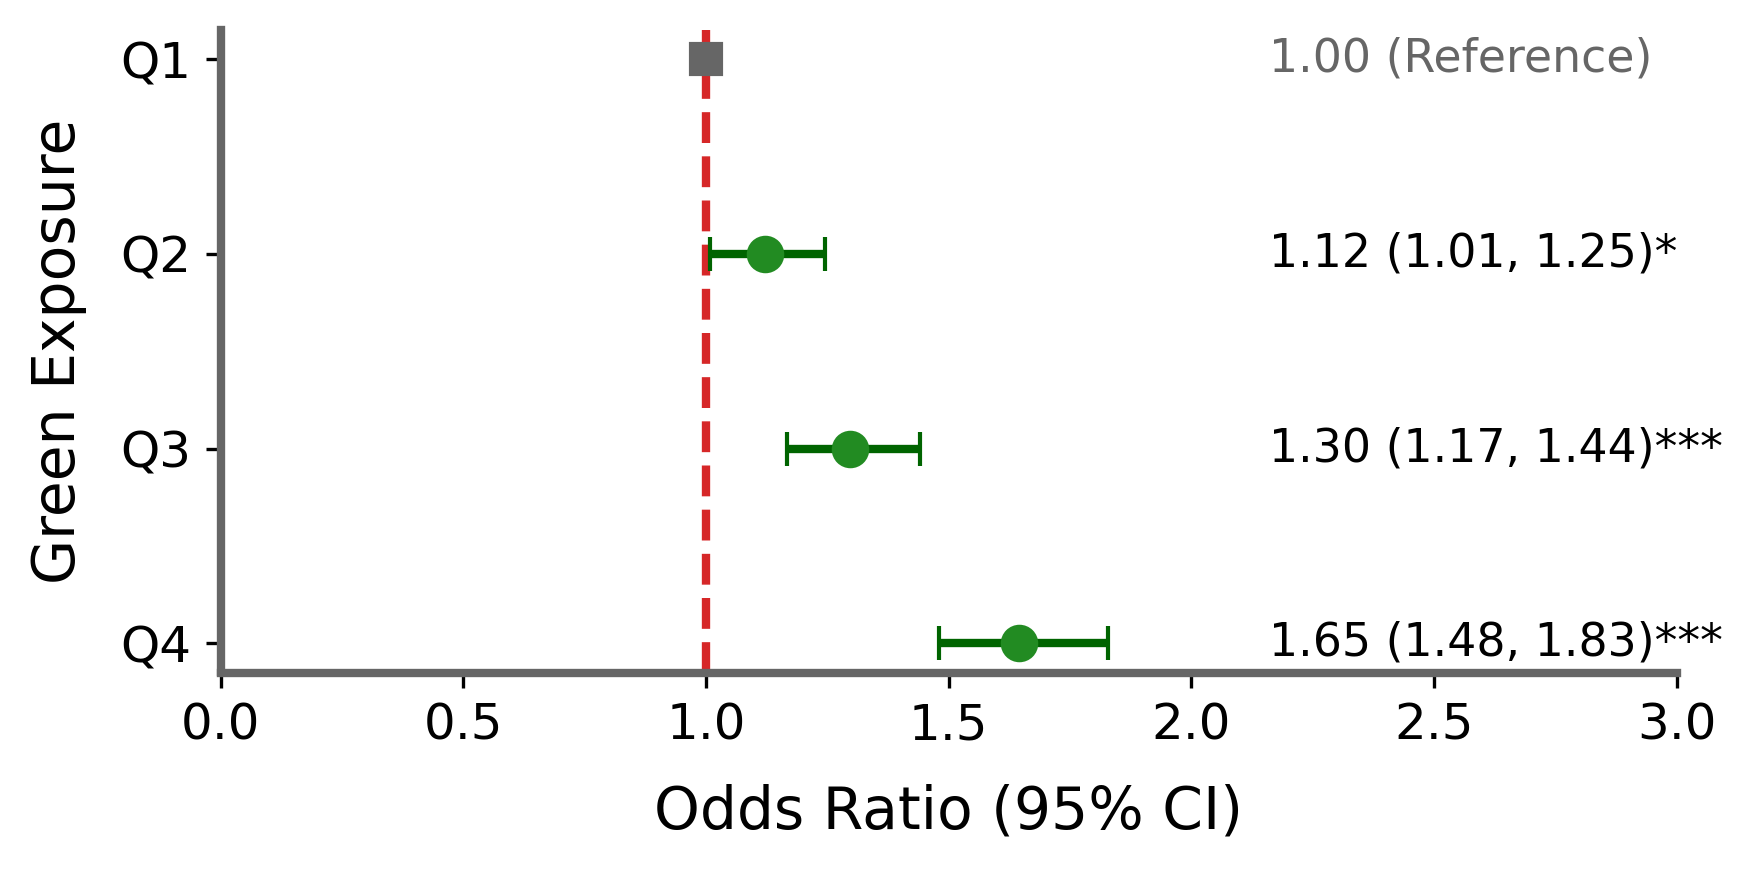

In [18]:
out_path = f"outputs/ordinal/mental_ordinal/quartiles/unadjusted/ordinal_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_ordinal[2]
predictor = cols.greenspace_quartiles[2]
df_plot = results_df.query(f"outcome == @outcome and predictor == @predictor")
ordinal.plot_forest(df_plot)#, save_path='out.png')

# Plot PROFILE – Mental Ordinal Score vs. Green Exposure Quartiles

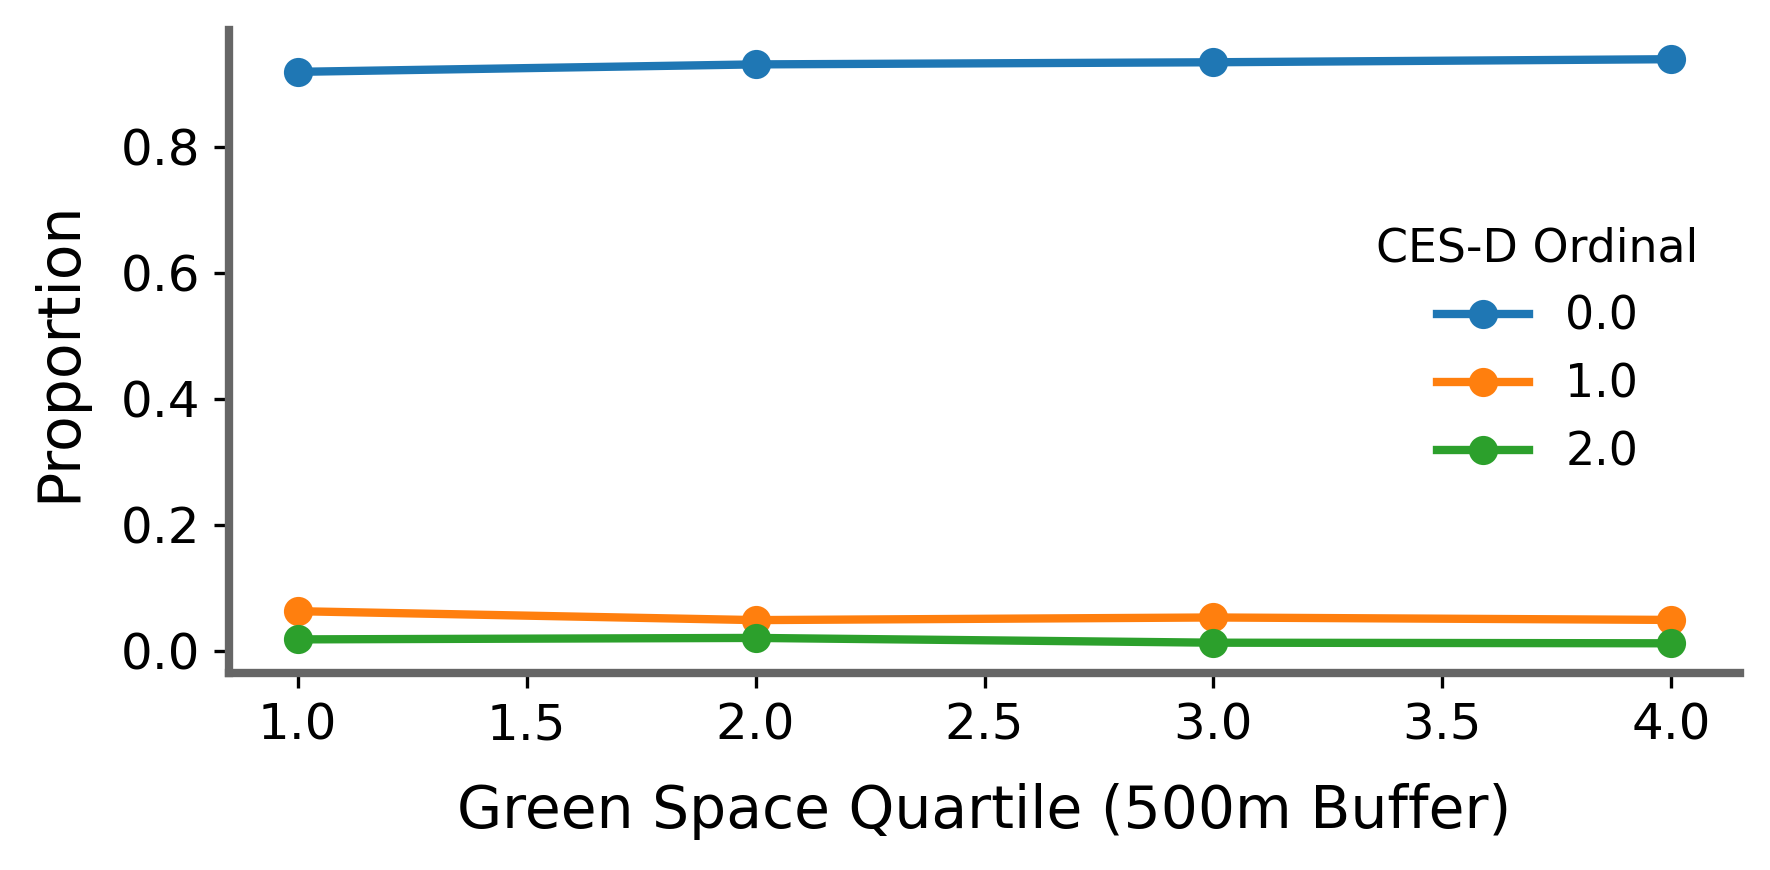

In [19]:
outcome = 'CES-D Ordinal'
predictor = 'Green Space Quartile (500m Buffer)'
profile_table, fig, ax = ordinal.plot_profile(data, outcome, predictor, predictor_type='categorical')

# Ordinal Model – Single Mental Health Variable

In [20]:
data = data_complete.copy()

outcome = cols.mental_ordinal[2]
predictor = cols.greenspace_quartiles[1]
#predictor = cols.ndvi[2]

result, metadata = ordinal.fit_model(data, outcome, predictor, predictor_type="categorical")#, covariates=['Sex', 'Age'])

In [21]:
results_df = ordinal.extract_results(
    result,
    metadata
)
print(f"outcome: {metadata['outcome']}, \npredictor: {metadata['predictor']}")
display(results_df)

outcome: SWLS Ordinal, 
predictor: Green Space Quartile (200m Buffer)


,reference_level,level,beta,OR,CI_lower,CI_upper,OR_95CI,p_value,p_value_fmt,pct_change_odds,interpretation,covariates
0,Q1,Q2,0.133,1.142,1.027,1.269,"1.142 (1.027, 1.269)",1.376376e-02,0.014,14.2,14.2% higher odds of better outcome (SWLS Ordi...,unadjusted
1,Q1,Q3,0.260,1.297,1.167,1.441,"1.297 (1.167, 1.441)",1.409785e-06,<0.001,29.7,29.7% higher odds of better outcome (SWLS Ordi...,unadjusted
2,Q1,Q4,0.499,1.648,1.482,1.832,"1.648 (1.482, 1.832)",2.263284e-20,<0.001,64.8,64.8% higher odds of better outcome (SWLS Ordi...,unadjusted


# Stratified Ordinal Model – Experiments

## SES-stratified: Mental Ordinal Scores across NDVI

In [32]:
data = data_complete.copy()

outcomes = cols.mental_ordinal
predictors = cols.ndvi

strata_results, strata_summary = experiment.run_stratified_grid(
    data                  = data,
    outcomes              = outcomes,
    predictors            = predictors,
    stratify_by           = "Socioeconomic Status (Tiers)",
#    strata                = [1, 2, 3],
    model_type            = "ordinal",
    predictor_type        = "continuous",
    scale_predictor       = 0.1,
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Sex", "Age"]
)

display(strata_results)

  [1/12] CES-D Ordinal × NDVI (100m Buffer)  [stratified by Socioeconomic Status (Tiers), ordinal]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [2/12] CES-D Ordinal × NDVI (200m Buffer)  [stratified by Socioeconomic Status (Tiers), ordinal]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [3/12] CES-D Ordinal × NDVI (500m Buffer)  [stratified by Socioeconomic Status (Tiers), ordinal]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [4/12] CES-D Ordinal × NDVI (1000m Buffer)  [stratified by Socioeconomic Status (Tiers), ordinal]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (T

,outcome,predictor,predictor_type,n,stratum_var,stratum,outcome_direction,scale_predictor,reference_level,level,beta,OR,CI_lower,CI_upper,OR_95CI,p_value,p_value_fmt,pct_change_odds,interpretation,covariates
0,CES-D Ordinal,NDVI (100m Buffer),continuous,1798,Socioeconomic Status (Tiers),1.0,higher_is_worse,0.1,None,NDVI (100m Buffer),-0.170,0.844,0.716,0.994,"0.844 (0.716, 0.994)",4.276976e-02,0.043,15.6,15.6% lower odds of more severe depressive sym...,"Sex, Age"
1,CES-D Ordinal,NDVI (100m Buffer),continuous,5475,Socioeconomic Status (Tiers),2.0,higher_is_worse,0.1,None,NDVI (100m Buffer),-0.194,0.823,0.719,0.943,"0.823 (0.719, 0.943)",4.928689e-03,0.005,17.7,17.7% lower odds of more severe depressive sym...,"Sex, Age"
2,CES-D Ordinal,NDVI (100m Buffer),continuous,1844,Socioeconomic Status (Tiers),3.0,higher_is_worse,0.1,None,NDVI (100m Buffer),-0.317,0.728,0.562,0.943,"0.728 (0.562, 0.943)",1.633575e-02,0.016,27.2,27.2% lower odds of more severe depressive sym...,"Sex, Age"
3,CES-D Ordinal,NDVI (200m Buffer),continuous,1798,Socioeconomic Status (Tiers),1.0,higher_is_worse,0.1,None,NDVI (200m Buffer),-0.177,0.838,0.702,0.999,"0.838 (0.702, 0.999)",4.876654e-02,0.049,16.2,16.2% lower odds of more severe depressive sym...,"Sex, Age"
4,CES-D Ordinal,NDVI (200m Buffer),continuous,5475,Socioeconomic Status (Tiers),2.0,higher_is_worse,0.1,None,NDVI (200m Buffer),-0.261,0.771,0.668,0.889,"0.771 (0.668, 0.889)",3.440330e-04,<0.001,22.9,22.9% lower odds of more severe depressive sym...,"Sex, Age"
5,CES-D Ordinal,NDVI (200m Buffer),continuous,1844,Socioeconomic Status (Tiers),3.0,higher_is_worse,0.1,None,NDVI (200m Buffer),-0.346,0.707,0.540,0.926,"0.707 (0.540, 0.926)",1.184484e-02,0.012,29.3,29.3% lower odds of more severe depressive sym...,"Sex, Age"
6,CES-D Ordinal,NDVI (500m Buffer),continuous,1798,Socioeconomic Status (Tiers),1.0,higher_is_worse,0.1,None,NDVI (500m Buffer),-0.202,0.817,0.679,0.982,"0.817 (0.679, 0.982)",3.108852e-02,0.031,18.3,18.3% lower odds of more severe depressive sym...,"Sex, Age"
7,CES-D Ordinal,NDVI (500m Buffer),continuous,5475,Socioeconomic Status (Tiers),2.0,higher_is_worse,0.1,None,NDVI (500m Buffer),-0.221,0.802,0.693,0.928,"0.802 (0.693, 0.928)",3.088809e-03,0.003,19.8,19.8% lower odds of more severe depressive sym...,"Sex, Age"
8,CES-D Ordinal,NDVI (500m Buffer),continuous,1844,Socioeconomic Status (Tiers),3.0,higher_is_worse,0.1,None,NDVI (500m Buffer),-0.204,0.815,0.621,1.069,"0.815 (0.621, 1.069)",1.397815e-01,0.140,18.5,18.5% lower odds of more severe depressive sym...,"Sex, Age"
9,CES-D Ordinal,NDVI (1000m Buffer),continuous,1798,Socioeconomic Status (Tiers),1.0,higher_is_worse,0.1,None,NDVI (1000m Buffer),-0.200,0.819,0.673,0.996,"0.819 (0.673, 0.996)",4.569864e-02,0.046,18.1,18.1% lower odds of more severe depressive sym...,"Sex, Age"


## Save Stratified Regression results to `ordinal_results` in `pkl` and `csv`

In [33]:
##out_path = f"outputs/ordinal/stratified_ses/mental_ordinal/ndvi/adjusted/ordinal_results"
##experiment.save_results(strata_results, strata_summary, path=out_path)

  Saved pickle : outputs/ordinal/stratified_ses/mental_ordinal/ndvi/adjusted/ordinal_results.pkl
  Saved CSV    : outputs/ordinal/stratified_ses/mental_ordinal/ndvi/adjusted/ordinal_results.csv


## SES-stratified: Mental Ordinal Scores across Green Space Quartiles

In [44]:
data = data_complete.copy()

outcomes = cols.mental_ordinal
predictors = cols.greenspace_quartiles

strata_results, strata_summary = experiment.run_stratified_grid(
    data                  = data,
    outcomes              = outcomes,
    predictors            = predictors,
    stratify_by           = "Socioeconomic Status (Tiers)",
#    strata                = [1, 2, 3],
    model_type            = "ordinal",
    predictor_type        = "categorical",
    reference_category    = "1.0",
    label_mapping         = {"1.0": "Q1", "2.0": "Q2", "3.0": "Q3", "4.0": "Q4"},
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Sex", "Age"]
)

display(strata_results)

  [1/12] CES-D Ordinal × Green Space Quartile (100m Buffer)  [stratified by Socioeconomic Status (Tiers), ordinal]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [2/12] CES-D Ordinal × Green Space Quartile (200m Buffer)  [stratified by Socioeconomic Status (Tiers), ordinal]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [3/12] CES-D Ordinal × Green Space Quartile (500m Buffer)  [stratified by Socioeconomic Status (Tiers), ordinal]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [4/12] CES-D Ordinal × Green Space Quartile (1000m Buffer)  [stratified by Socioeconomic Status (Tiers), ordinal]
  Stratum Socioeconomic St

,outcome,predictor,predictor_type,n,stratum_var,stratum,outcome_direction,reference_category,reference_level,level,beta,OR,CI_lower,CI_upper,OR_95CI,p_value,p_value_fmt,pct_change_odds,interpretation,covariates
0,CES-D Ordinal,Green Space Quartile (100m Buffer),categorical,1788,Socioeconomic Status (Tiers),1.0,higher_is_worse,1.0,Q1,Q2,0.018,1.019,0.705,1.473,"1.019 (0.705, 1.473)",9.217451e-01,0.922,1.9,1.9% higher odds of more severe depressive sym...,"Sex, Age"
1,CES-D Ordinal,Green Space Quartile (100m Buffer),categorical,1788,Socioeconomic Status (Tiers),1.0,higher_is_worse,1.0,Q1,Q3,-0.144,0.866,0.581,1.291,"0.866 (0.581, 1.291)",4.796723e-01,0.480,13.4,13.4% lower odds of more severe depressive sym...,"Sex, Age"
2,CES-D Ordinal,Green Space Quartile (100m Buffer),categorical,1788,Socioeconomic Status (Tiers),1.0,higher_is_worse,1.0,Q1,Q4,-0.186,0.830,0.544,1.268,"0.830 (0.544, 1.268)",3.895885e-01,0.390,17.0,17.0% lower odds of more severe depressive sym...,"Sex, Age"
3,CES-D Ordinal,Green Space Quartile (100m Buffer),categorical,5449,Socioeconomic Status (Tiers),2.0,higher_is_worse,1.0,Q1,Q2,-0.236,0.789,0.572,1.090,"0.789 (0.572, 1.090)",1.503897e-01,0.150,21.1,21.1% lower odds of more severe depressive sym...,"Sex, Age"
4,CES-D Ordinal,Green Space Quartile (100m Buffer),categorical,5449,Socioeconomic Status (Tiers),2.0,higher_is_worse,1.0,Q1,Q3,-0.025,0.975,0.717,1.326,"0.975 (0.717, 1.326)",8.710530e-01,0.871,2.5,2.5% lower odds of more severe depressive symp...,"Sex, Age"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,SWLS Ordinal,Green Space Quartile (1000m Buffer),categorical,5564,Socioeconomic Status (Tiers),2.0,higher_is_better,1.0,Q1,Q3,0.124,1.132,0.985,1.300,"1.132 (0.985, 1.300)",8.038898e-02,0.080,13.2,13.2% higher odds of better life satisfaction ...,"Sex, Age"
104,SWLS Ordinal,Green Space Quartile (1000m Buffer),categorical,5564,Socioeconomic Status (Tiers),2.0,higher_is_better,1.0,Q1,Q4,0.468,1.596,1.392,1.830,"1.596 (1.392, 1.830)",2.114747e-11,<0.001,59.6,59.6% higher odds of better life satisfaction ...,"Sex, Age"
105,SWLS Ordinal,Green Space Quartile (1000m Buffer),categorical,1868,Socioeconomic Status (Tiers),3.0,higher_is_better,1.0,Q1,Q2,0.072,1.074,0.833,1.385,"1.074 (0.833, 1.385)",5.801853e-01,0.580,7.4,7.4% higher odds of better life satisfaction c...,"Sex, Age"
106,SWLS Ordinal,Green Space Quartile (1000m Buffer),categorical,1868,Socioeconomic Status (Tiers),3.0,higher_is_better,1.0,Q1,Q3,0.195,1.216,0.958,1.543,"1.216 (0.958, 1.543)",1.082291e-01,0.108,21.6,21.6% higher odds of better life satisfaction ...,"Sex, Age"


## Save Stratified Regression results to `ordinal_results` in `pkl` and `csv`

In [45]:
##out_path = f"outputs/ordinal/stratified_ses/mental_ordinal/quartiles/adjusted/ordinal_results"
##experiment.save_results(strata_results, strata_summary, path=out_path)

  Saved pickle : outputs/ordinal/stratified_ses/mental_ordinal/quartiles/adjusted/ordinal_results.pkl
  Saved CSV    : outputs/ordinal/stratified_ses/mental_ordinal/quartiles/adjusted/ordinal_results.csv


# Analysis – SES-Stratified Ordinal Model

## Mental Scores vs. NDVI – unadjusted

In [46]:
out_path = f"outputs/ordinal/stratified_ses/mental_ordinal/ndvi/unadjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T20:04:39.606525


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
6,CES-D Ordinal,NDVI (500m Buffer),1798,Socioeconomic Status (Tiers),1.0,0.1,-0.245,"0.782 (0.653, 0.938)",0.008,21.8,21.8% lower odds of more severe depressive sym...,unadjusted
7,CES-D Ordinal,NDVI (500m Buffer),5475,Socioeconomic Status (Tiers),2.0,0.1,-0.238,"0.788 (0.683, 0.910)",0.001,21.2,21.2% lower odds of more severe depressive sym...,unadjusted
8,CES-D Ordinal,NDVI (500m Buffer),1844,Socioeconomic Status (Tiers),3.0,0.1,-0.213,"0.808 (0.616, 1.061)",0.125,19.2,19.2% lower odds of more severe depressive sym...,unadjusted
18,GAD-7 Ordinal,NDVI (500m Buffer),1842,Socioeconomic Status (Tiers),1.0,0.1,-0.176,"0.839 (0.743, 0.947)",0.005,16.1,16.1% lower odds of more severe anxiety sympto...,unadjusted
19,GAD-7 Ordinal,NDVI (500m Buffer),5573,Socioeconomic Status (Tiers),2.0,0.1,-0.105,"0.900 (0.836, 0.969)",0.005,10.0,10.0% lower odds of more severe anxiety sympto...,unadjusted
20,GAD-7 Ordinal,NDVI (500m Buffer),1863,Socioeconomic Status (Tiers),3.0,0.1,-0.025,"0.975 (0.860, 1.106)",0.691,2.5,2.5% lower odds of more severe anxiety symptom...,unadjusted
30,SWLS Ordinal,NDVI (500m Buffer),1836,Socioeconomic Status (Tiers),1.0,0.1,0.146,"1.157 (1.040, 1.287)",0.008,15.7,15.7% higher odds of better life satisfaction ...,unadjusted
31,SWLS Ordinal,NDVI (500m Buffer),5591,Socioeconomic Status (Tiers),2.0,0.1,0.243,"1.276 (1.197, 1.360)",<0.001,27.6,27.6% higher odds of better life satisfaction ...,unadjusted
32,SWLS Ordinal,NDVI (500m Buffer),1870,Socioeconomic Status (Tiers),3.0,0.1,0.120,"1.127 (1.018, 1.248)",0.021,12.7,12.7% higher odds of better life satisfaction ...,unadjusted


## Mental Scores vs. NDVI – adjusted: Sex, Age

In [47]:
out_path = f"outputs/ordinal/stratified_ses/mental_ordinal/ndvi/adjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T20:05:20.223539


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
6,CES-D Ordinal,NDVI (500m Buffer),1798,Socioeconomic Status (Tiers),1.0,0.1,-0.202,"0.817 (0.679, 0.982)",0.031,18.3,18.3% lower odds of more severe depressive sym...,"Sex, Age"
7,CES-D Ordinal,NDVI (500m Buffer),5475,Socioeconomic Status (Tiers),2.0,0.1,-0.221,"0.802 (0.693, 0.928)",0.003,19.8,19.8% lower odds of more severe depressive sym...,"Sex, Age"
8,CES-D Ordinal,NDVI (500m Buffer),1844,Socioeconomic Status (Tiers),3.0,0.1,-0.204,"0.815 (0.621, 1.069)",0.140,18.5,18.5% lower odds of more severe depressive sym...,"Sex, Age"
18,GAD-7 Ordinal,NDVI (500m Buffer),1842,Socioeconomic Status (Tiers),1.0,0.1,-0.149,"0.862 (0.762, 0.974)",0.017,13.8,13.8% lower odds of more severe anxiety sympto...,"Sex, Age"
19,GAD-7 Ordinal,NDVI (500m Buffer),5573,Socioeconomic Status (Tiers),2.0,0.1,-0.106,"0.899 (0.834, 0.969)",0.005,10.1,10.1% lower odds of more severe anxiety sympto...,"Sex, Age"
20,GAD-7 Ordinal,NDVI (500m Buffer),1863,Socioeconomic Status (Tiers),3.0,0.1,-0.030,"0.971 (0.855, 1.102)",0.647,2.9,2.9% lower odds of more severe anxiety symptom...,"Sex, Age"
30,SWLS Ordinal,NDVI (500m Buffer),1836,Socioeconomic Status (Tiers),1.0,0.1,0.120,"1.127 (1.013, 1.255)",0.028,12.7,12.7% higher odds of better life satisfaction ...,"Sex, Age"
31,SWLS Ordinal,NDVI (500m Buffer),5591,Socioeconomic Status (Tiers),2.0,0.1,0.227,"1.255 (1.177, 1.338)",<0.001,25.5,25.5% higher odds of better life satisfaction ...,"Sex, Age"
32,SWLS Ordinal,NDVI (500m Buffer),1870,Socioeconomic Status (Tiers),3.0,0.1,0.125,"1.133 (1.023, 1.255)",0.017,13.3,13.3% higher odds of better life satisfaction ...,"Sex, Age"


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [48]:
out_path = f"outputs/ordinal/stratified_ses/mental_ordinal/quartiles/unadjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T20:10:54.439775


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
20,CES-D Ordinal,Green Space Quartile (500m Buffer),1788,Socioeconomic Status (Tiers),1.0,Q1,Q4,-0.833,"0.435 (0.264, 0.716)",0.001,56.5,56.5% lower odds of more severe depressive sym...,unadjusted
23,CES-D Ordinal,Green Space Quartile (500m Buffer),5449,Socioeconomic Status (Tiers),2.0,Q1,Q4,-0.022,"0.978 (0.725, 1.319)",0.883,2.2,2.2% lower odds of more severe depressive symp...,unadjusted
26,CES-D Ordinal,Green Space Quartile (500m Buffer),1842,Socioeconomic Status (Tiers),3.0,Q1,Q4,-0.118,"0.888 (0.488, 1.617)",0.698,11.2,11.2% lower odds of more severe depressive sym...,unadjusted
56,GAD-7 Ordinal,Green Space Quartile (500m Buffer),1831,Socioeconomic Status (Tiers),1.0,Q1,Q4,-0.389,"0.678 (0.510, 0.902)",0.008,32.2,32.2% lower odds of more severe anxiety sympto...,unadjusted
59,GAD-7 Ordinal,Green Space Quartile (500m Buffer),5546,Socioeconomic Status (Tiers),2.0,Q1,Q4,-0.040,"0.961 (0.819, 1.126)",0.620,3.9,3.9% lower odds of more severe anxiety symptom...,unadjusted
62,GAD-7 Ordinal,Green Space Quartile (500m Buffer),1861,Socioeconomic Status (Tiers),3.0,Q1,Q4,-0.056,"0.946 (0.713, 1.254)",0.698,5.4,5.4% lower odds of more severe anxiety symptom...,unadjusted
92,SWLS Ordinal,Green Space Quartile (500m Buffer),1825,Socioeconomic Status (Tiers),1.0,Q1,Q4,0.411,"1.508 (1.182, 1.923)",<0.001,50.8,50.8% higher odds of better life satisfaction ...,unadjusted
95,SWLS Ordinal,Green Space Quartile (500m Buffer),5564,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.473,"1.604 (1.397, 1.843)",<0.001,60.4,60.4% higher odds of better life satisfaction ...,unadjusted
98,SWLS Ordinal,Green Space Quartile (500m Buffer),1868,Socioeconomic Status (Tiers),3.0,Q1,Q4,0.357,"1.428 (1.134, 1.799)",0.002,42.8,42.8% higher odds of better life satisfaction ...,unadjusted


## Mental Scores vs. Land-use-based Quartiles – adjusted: Sex, Age

In [49]:
out_path = f"outputs/ordinal/stratified_ses/mental_ordinal/quartiles/adjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T20:11:31.674463


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
20,CES-D Ordinal,Green Space Quartile (500m Buffer),1788,Socioeconomic Status (Tiers),1.0,Q1,Q4,-0.763,"0.466 (0.281, 0.772)",0.003,53.4,53.4% lower odds of more severe depressive sym...,"Sex, Age"
23,CES-D Ordinal,Green Space Quartile (500m Buffer),5449,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.001,"1.001 (0.741, 1.352)",0.996,0.1,0.1% higher odds of more severe depressive sym...,"Sex, Age"
26,CES-D Ordinal,Green Space Quartile (500m Buffer),1842,Socioeconomic Status (Tiers),3.0,Q1,Q4,-0.155,"0.857 (0.468, 1.567)",0.616,14.3,14.3% lower odds of more severe depressive sym...,"Sex, Age"
56,GAD-7 Ordinal,Green Space Quartile (500m Buffer),1831,Socioeconomic Status (Tiers),1.0,Q1,Q4,-0.343,"0.710 (0.532, 0.947)",0.020,29.0,29.0% lower odds of more severe anxiety sympto...,"Sex, Age"
59,GAD-7 Ordinal,Green Space Quartile (500m Buffer),5546,Socioeconomic Status (Tiers),2.0,Q1,Q4,-0.028,"0.972 (0.828, 1.141)",0.729,2.8,2.8% lower odds of more severe anxiety symptom...,"Sex, Age"
62,GAD-7 Ordinal,Green Space Quartile (500m Buffer),1861,Socioeconomic Status (Tiers),3.0,Q1,Q4,-0.080,"0.923 (0.695, 1.226)",0.580,7.7,7.7% lower odds of more severe anxiety symptom...,"Sex, Age"
92,SWLS Ordinal,Green Space Quartile (500m Buffer),1825,Socioeconomic Status (Tiers),1.0,Q1,Q4,0.367,"1.444 (1.129, 1.847)",0.003,44.4,44.4% higher odds of better life satisfaction ...,"Sex, Age"
95,SWLS Ordinal,Green Space Quartile (500m Buffer),5564,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.465,"1.592 (1.386, 1.829)",<0.001,59.2,59.2% higher odds of better life satisfaction ...,"Sex, Age"
98,SWLS Ordinal,Green Space Quartile (500m Buffer),1868,Socioeconomic Status (Tiers),3.0,Q1,Q4,0.353,"1.423 (1.130, 1.793)",0.003,42.3,42.3% higher odds of better life satisfaction ...,"Sex, Age"


# Analysis – Age-Stratified Ordinal Model

## Mental Scores vs. NDVI – unadjusted

In [50]:
out_path = f"outputs/ordinal/stratified_age/mental_ordinal/ndvi/unadjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T20:01:52.476483


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
8,CES-D Ordinal,NDVI (500m Buffer),373,Age_group,"[18, 40)",0.1,0.244,"1.276 (0.803, 2.030)",0.303,27.6,27.6% higher odds of more severe depressive sy...,unadjusted
9,CES-D Ordinal,NDVI (500m Buffer),3202,Age_group,"[40, 53)",0.1,-0.243,"0.784 (0.668, 0.920)",0.003,21.6,21.6% lower odds of more severe depressive sym...,unadjusted
10,CES-D Ordinal,NDVI (500m Buffer),2649,Age_group,"[53, 65)",0.1,-0.326,"0.722 (0.604, 0.863)",<0.001,27.8,27.8% lower odds of more severe depressive sym...,unadjusted
11,CES-D Ordinal,NDVI (500m Buffer),2918,Age_group,"[65, 81)",0.1,-0.218,"0.804 (0.645, 1.003)",0.054,19.6,19.6% lower odds of more severe depressive sym...,unadjusted
24,GAD-7 Ordinal,NDVI (500m Buffer),375,Age_group,"[18, 40)",0.1,-0.007,"0.993 (0.753, 1.308)",0.958,0.7,0.7% lower odds of more severe anxiety symptom...,unadjusted
25,GAD-7 Ordinal,NDVI (500m Buffer),3237,Age_group,"[40, 53)",0.1,-0.098,"0.907 (0.827, 0.994)",0.036,9.3,9.3% lower odds of more severe anxiety symptom...,unadjusted
26,GAD-7 Ordinal,NDVI (500m Buffer),2711,Age_group,"[53, 65)",0.1,-0.141,"0.868 (0.783, 0.963)",0.008,13.2,13.2% lower odds of more severe anxiety sympto...,unadjusted
27,GAD-7 Ordinal,NDVI (500m Buffer),2981,Age_group,"[65, 81)",0.1,-0.125,"0.883 (0.795, 0.981)",0.020,11.7,11.7% lower odds of more severe anxiety sympto...,unadjusted
40,SWLS Ordinal,NDVI (500m Buffer),377,Age_group,"[18, 40)",0.1,0.106,"1.112 (0.888, 1.391)",0.355,11.2,11.2% higher odds of better life satisfaction ...,unadjusted
41,SWLS Ordinal,NDVI (500m Buffer),3241,Age_group,"[40, 53)",0.1,0.280,"1.323 (1.223, 1.432)",<0.001,32.3,32.3% higher odds of better life satisfaction ...,unadjusted


## Mental Scores vs. NDVI – adjusted: Sex, SES

In [51]:
out_path = f"outputs/ordinal/stratified_age/mental_ordinal/ndvi/adjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T20:02:20.575205


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
8,CES-D Ordinal,NDVI (500m Buffer),365,Age_group,"[18, 40)",0.1,0.240,"1.271 (0.784, 2.061)",0.331,27.1,27.1% higher odds of more severe depressive sy...,"Sex, Socioeconomic Status (Tiers)"
9,CES-D Ordinal,NDVI (500m Buffer),3199,Age_group,"[40, 53)",0.1,-0.237,"0.789 (0.669, 0.932)",0.005,21.1,21.1% lower odds of more severe depressive sym...,"Sex, Socioeconomic Status (Tiers)"
10,CES-D Ordinal,NDVI (500m Buffer),2644,Age_group,"[53, 65)",0.1,-0.326,"0.722 (0.599, 0.870)",<0.001,27.8,27.8% lower odds of more severe depressive sym...,"Sex, Socioeconomic Status (Tiers)"
11,CES-D Ordinal,NDVI (500m Buffer),2909,Age_group,"[65, 81)",0.1,-0.183,"0.832 (0.666, 1.041)",0.107,16.8,16.8% lower odds of more severe depressive sym...,"Sex, Socioeconomic Status (Tiers)"
24,GAD-7 Ordinal,NDVI (500m Buffer),367,Age_group,"[18, 40)",0.1,-0.030,"0.971 (0.732, 1.288)",0.837,2.9,2.9% lower odds of more severe anxiety symptom...,"Sex, Socioeconomic Status (Tiers)"
25,GAD-7 Ordinal,NDVI (500m Buffer),3234,Age_group,"[40, 53)",0.1,-0.092,"0.913 (0.831, 1.002)",0.054,8.7,8.7% lower odds of more severe anxiety symptom...,"Sex, Socioeconomic Status (Tiers)"
26,GAD-7 Ordinal,NDVI (500m Buffer),2706,Age_group,"[53, 65)",0.1,-0.140,"0.869 (0.782, 0.966)",0.009,13.1,13.1% lower odds of more severe anxiety sympto...,"Sex, Socioeconomic Status (Tiers)"
27,GAD-7 Ordinal,NDVI (500m Buffer),2971,Age_group,"[65, 81)",0.1,-0.104,"0.901 (0.810, 1.002)",0.055,9.9,9.9% lower odds of more severe anxiety symptom...,"Sex, Socioeconomic Status (Tiers)"
40,SWLS Ordinal,NDVI (500m Buffer),369,Age_group,"[18, 40)",0.1,0.137,"1.147 (0.914, 1.440)",0.237,14.7,14.7% higher odds of better life satisfaction ...,"Sex, Socioeconomic Status (Tiers)"
41,SWLS Ordinal,NDVI (500m Buffer),3238,Age_group,"[40, 53)",0.1,0.284,"1.329 (1.227, 1.439)",<0.001,32.9,32.9% higher odds of better life satisfaction ...,"Sex, Socioeconomic Status (Tiers)"


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [52]:
out_path = f"outputs/ordinal/stratified_age/mental_ordinal/quartiles/unadjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T20:06:58.859299


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
26,CES-D Ordinal,Green Space Quartile (500m Buffer),370,Age_group,"[18, 40)",Q1,Q4,0.616,"1.852 (0.701, 4.888)",0.214,85.2,85.2% higher odds of more severe depressive sy...,unadjusted
29,CES-D Ordinal,Green Space Quartile (500m Buffer),3191,Age_group,"[40, 53)",Q1,Q4,-0.597,"0.550 (0.385, 0.787)",0.001,45.0,45.0% lower odds of more severe depressive sym...,unadjusted
32,CES-D Ordinal,Green Space Quartile (500m Buffer),2638,Age_group,"[53, 65)",Q1,Q4,-0.197,"0.822 (0.547, 1.233)",0.343,17.8,17.8% lower odds of more severe depressive sym...,unadjusted
35,CES-D Ordinal,Green Space Quartile (500m Buffer),2905,Age_group,"[65, 81)",Q1,Q4,-0.159,"0.853 (0.517, 1.406)",0.533,14.7,14.7% lower odds of more severe depressive sym...,unadjusted
74,GAD-7 Ordinal,Green Space Quartile (500m Buffer),372,Age_group,"[18, 40)",Q1,Q4,0.256,"1.292 (0.713, 2.340)",0.398,29.2,29.2% higher odds of more severe anxiety sympt...,unadjusted
77,GAD-7 Ordinal,Green Space Quartile (500m Buffer),3225,Age_group,"[40, 53)",Q1,Q4,-0.312,"0.732 (0.600, 0.894)",0.002,26.8,26.8% lower odds of more severe anxiety sympto...,unadjusted
80,GAD-7 Ordinal,Green Space Quartile (500m Buffer),2700,Age_group,"[53, 65)",Q1,Q4,-0.109,"0.896 (0.714, 1.125)",0.346,10.4,10.4% lower odds of more severe anxiety sympto...,unadjusted
83,GAD-7 Ordinal,Green Space Quartile (500m Buffer),2967,Age_group,"[65, 81)",Q1,Q4,-0.053,"0.948 (0.751, 1.198)",0.655,5.2,5.2% lower odds of more severe anxiety symptom...,unadjusted
122,SWLS Ordinal,Green Space Quartile (500m Buffer),374,Age_group,"[18, 40)",Q1,Q4,0.043,"1.044 (0.640, 1.702)",0.864,4.4,4.4% higher odds of better life satisfaction c...,unadjusted
125,SWLS Ordinal,Green Space Quartile (500m Buffer),3229,Age_group,"[40, 53)",Q1,Q4,0.740,"2.096 (1.763, 2.491)",<0.001,109.6,109.6% higher odds of better life satisfaction...,unadjusted


## Mental Scores vs. Land-use-based Quartiles – adjusted: Sex, SES

In [53]:
out_path = f"outputs/ordinal/stratified_age/mental_ordinal/quartiles/adjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T20:07:47.108544


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
26,CES-D Ordinal,Green Space Quartile (500m Buffer),362,Age_group,"[18, 40)",Q1,Q4,0.791,"2.205 (0.805, 6.035)",0.124,120.5,120.5% higher odds of more severe depressive s...,"Sex, Socioeconomic Status (Tiers)"
29,CES-D Ordinal,Green Space Quartile (500m Buffer),3188,Age_group,"[40, 53)",Q1,Q4,-0.467,"0.627 (0.435, 0.903)",0.012,37.3,37.3% lower odds of more severe depressive sym...,"Sex, Socioeconomic Status (Tiers)"
32,CES-D Ordinal,Green Space Quartile (500m Buffer),2633,Age_group,"[53, 65)",Q1,Q4,-0.089,"0.915 (0.605, 1.383)",0.673,8.5,8.5% lower odds of more severe depressive symp...,"Sex, Socioeconomic Status (Tiers)"
35,CES-D Ordinal,Green Space Quartile (500m Buffer),2896,Age_group,"[65, 81)",Q1,Q4,-0.067,"0.936 (0.565, 1.549)",0.796,6.4,6.4% lower odds of more severe depressive symp...,"Sex, Socioeconomic Status (Tiers)"
74,GAD-7 Ordinal,Green Space Quartile (500m Buffer),364,Age_group,"[18, 40)",Q1,Q4,0.344,"1.411 (0.763, 2.610)",0.273,41.1,41.1% higher odds of more severe anxiety sympt...,"Sex, Socioeconomic Status (Tiers)"
77,GAD-7 Ordinal,Green Space Quartile (500m Buffer),3222,Age_group,"[40, 53)",Q1,Q4,-0.255,"0.775 (0.633, 0.949)",0.014,22.5,22.5% lower odds of more severe anxiety sympto...,"Sex, Socioeconomic Status (Tiers)"
80,GAD-7 Ordinal,Green Space Quartile (500m Buffer),2695,Age_group,"[53, 65)",Q1,Q4,-0.070,"0.932 (0.740, 1.174)",0.550,6.8,6.8% lower odds of more severe anxiety symptom...,"Sex, Socioeconomic Status (Tiers)"
83,GAD-7 Ordinal,Green Space Quartile (500m Buffer),2957,Age_group,"[65, 81)",Q1,Q4,0.003,"1.003 (0.791, 1.272)",0.978,0.3,0.3% higher odds of more severe anxiety sympto...,"Sex, Socioeconomic Status (Tiers)"
122,SWLS Ordinal,Green Space Quartile (500m Buffer),366,Age_group,"[18, 40)",Q1,Q4,0.036,"1.037 (0.630, 1.708)",0.886,3.7,3.7% higher odds of better life satisfaction c...,"Sex, Socioeconomic Status (Tiers)"
125,SWLS Ordinal,Green Space Quartile (500m Buffer),3226,Age_group,"[40, 53)",Q1,Q4,0.649,"1.913 (1.606, 2.278)",<0.001,91.3,91.3% higher odds of better life satisfaction ...,"Sex, Socioeconomic Status (Tiers)"


# Analysis – Sex-Stratified Ordinal Model

## Mental Scores vs. NDVI – unadjusted

In [54]:
out_path = f"outputs/ordinal/stratified_sex/mental_ordinal/ndvi/unadjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T20:03:11.869551


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
4,CES-D Ordinal,NDVI (500m Buffer),4441,Sex,0,0.1,-0.283,"0.754 (0.627, 0.907)",0.003,24.6,24.6% lower odds of more severe depressive sym...,unadjusted
5,CES-D Ordinal,NDVI (500m Buffer),4701,Sex,1,0.1,-0.237,"0.789 (0.697, 0.893)",<0.001,21.1,21.1% lower odds of more severe depressive sym...,unadjusted
12,GAD-7 Ordinal,NDVI (500m Buffer),4447,Sex,0,0.1,-0.113,"0.893 (0.818, 0.974)",0.011,10.7,10.7% lower odds of more severe anxiety sympto...,unadjusted
13,GAD-7 Ordinal,NDVI (500m Buffer),4857,Sex,1,0.1,-0.101,"0.904 (0.839, 0.973)",0.007,9.6,9.6% lower odds of more severe anxiety symptom...,unadjusted
20,SWLS Ordinal,NDVI (500m Buffer),4460,Sex,0,0.1,0.213,"1.237 (1.155, 1.326)",<0.001,23.7,23.7% higher odds of better life satisfaction ...,unadjusted
21,SWLS Ordinal,NDVI (500m Buffer),4863,Sex,1,0.1,0.206,"1.229 (1.150, 1.314)",<0.001,22.9,22.9% higher odds of better life satisfaction ...,unadjusted


## Mental Scores vs. NDVI – adjusted: Age, SES

In [55]:
out_path = f"outputs/ordinal/stratified_sex/mental_ordinal/ndvi/adjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T20:03:40.854621


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
4,CES-D Ordinal,NDVI (500m Buffer),4432,Sex,0,0.1,-0.243,"0.784 (0.648, 0.948)",0.012,21.6,21.6% lower odds of more severe depressive sym...,"Age, Socioeconomic Status (Tiers)"
5,CES-D Ordinal,NDVI (500m Buffer),4685,Sex,1,0.1,-0.207,"0.813 (0.716, 0.923)",0.001,18.7,18.7% lower odds of more severe depressive sym...,"Age, Socioeconomic Status (Tiers)"
12,GAD-7 Ordinal,NDVI (500m Buffer),4436,Sex,0,0.1,-0.107,"0.898 (0.822, 0.982)",0.018,10.2,10.2% lower odds of more severe anxiety sympto...,"Age, Socioeconomic Status (Tiers)"
13,GAD-7 Ordinal,NDVI (500m Buffer),4842,Sex,1,0.1,-0.095,"0.909 (0.844, 0.980)",0.013,9.1,9.1% lower odds of more severe anxiety symptom...,"Age, Socioeconomic Status (Tiers)"
20,SWLS Ordinal,NDVI (500m Buffer),4449,Sex,0,0.1,0.173,"1.189 (1.109, 1.275)",<0.001,18.9,18.9% higher odds of better life satisfaction ...,"Age, Socioeconomic Status (Tiers)"
21,SWLS Ordinal,NDVI (500m Buffer),4848,Sex,1,0.1,0.182,"1.200 (1.122, 1.283)",<0.001,20.0,20.0% higher odds of better life satisfaction ...,"Age, Socioeconomic Status (Tiers)"


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [56]:
out_path = f"outputs/ordinal/stratified_sex/mental_ordinal/quartiles/unadjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T20:08:36.665108


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
14,CES-D Ordinal,Green Space Quartile (500m Buffer),4424,Sex,0,Q1,Q4,-0.191,"0.826 (0.547, 1.248)",0.365,17.4,17.4% lower odds of more severe depressive sym...,unadjusted
17,CES-D Ordinal,Green Space Quartile (500m Buffer),4680,Sex,1,Q1,Q4,-0.350,"0.705 (0.534, 0.929)",0.013,29.5,29.5% lower odds of more severe depressive sym...,unadjusted
38,GAD-7 Ordinal,Green Space Quartile (500m Buffer),4429,Sex,0,Q1,Q4,-0.116,"0.890 (0.734, 1.080)",0.237,11.0,11.0% lower odds of more severe anxiety sympto...,unadjusted
41,GAD-7 Ordinal,Green Space Quartile (500m Buffer),4835,Sex,1,Q1,Q4,-0.156,"0.855 (0.727, 1.006)",0.058,14.5,14.5% lower odds of more severe anxiety sympto...,unadjusted
62,SWLS Ordinal,Green Space Quartile (500m Buffer),4442,Sex,0,Q1,Q4,0.452,"1.571 (1.348, 1.832)",<0.001,57.1,57.1% higher odds of better life satisfaction ...,unadjusted
65,SWLS Ordinal,Green Space Quartile (500m Buffer),4841,Sex,1,Q1,Q4,0.542,"1.719 (1.486, 1.989)",<0.001,71.9,71.9% higher odds of better life satisfaction ...,unadjusted


## Mental Scores vs. Land-use-based Quartiles – adjusted: Age, SES

In [57]:
out_path = f"outputs/ordinal/stratified_sex/mental_ordinal/quartiles/adjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T20:09:19.527596


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
14,CES-D Ordinal,Green Space Quartile (500m Buffer),4415,Sex,0,Q1,Q4,-0.058,"0.944 (0.621, 1.434)",0.786,5.6,5.6% lower odds of more severe depressive symp...,"Age, Socioeconomic Status (Tiers)"
17,CES-D Ordinal,Green Space Quartile (500m Buffer),4664,Sex,1,Q1,Q4,-0.244,"0.784 (0.592, 1.037)",0.088,21.6,21.6% lower odds of more severe depressive sym...,"Age, Socioeconomic Status (Tiers)"
38,GAD-7 Ordinal,Green Space Quartile (500m Buffer),4418,Sex,0,Q1,Q4,-0.084,"0.919 (0.757, 1.116)",0.396,8.1,8.1% lower odds of more severe anxiety symptom...,"Age, Socioeconomic Status (Tiers)"
41,GAD-7 Ordinal,Green Space Quartile (500m Buffer),4820,Sex,1,Q1,Q4,-0.109,"0.897 (0.762, 1.056)",0.190,10.3,10.3% lower odds of more severe anxiety sympto...,"Age, Socioeconomic Status (Tiers)"
62,SWLS Ordinal,Green Space Quartile (500m Buffer),4431,Sex,0,Q1,Q4,0.374,"1.454 (1.245, 1.697)",<0.001,45.4,45.4% higher odds of better life satisfaction ...,"Age, Socioeconomic Status (Tiers)"
65,SWLS Ordinal,Green Space Quartile (500m Buffer),4826,Sex,1,Q1,Q4,0.454,"1.575 (1.360, 1.824)",<0.001,57.5,57.5% higher odds of better life satisfaction ...,"Age, Socioeconomic Status (Tiers)"


# Stratified Ordinal Model – Single Mental Health Variable

In [58]:
data = data_complete.copy()

outcome   = "SWLS Ordinal"
predictor = "Green Space Quartile (500m Buffer)"

strata_results, strata_summary = ordinal.fit_stratified(
    data               = data,
    outcome            = outcome,
    predictor          = predictor,
    stratify_by        = "Age_group",
#    strata             = [1, 2, 3],
    predictor_type     = "categorical",
    reference_category = "1.0",
#    covariates         = ["Sex", "Socioeconomic Status (Tiers)"],
)

display(strata_summary.query(f"level == 'Q4'"))

  Stratum Age_group = [18, 40)  (n = 513)
  Stratum Age_group = [40, 53)  (n = 3383)
  Stratum Age_group = [53, 65)  (n = 2851)
  Stratum Age_group = [65, 81)  (n = 3253)


,stratum,reference_level,level,beta,OR,CI_lower,CI_upper,OR_95CI,p_value,p_value_fmt,pct_change_odds,interpretation,covariates
2,"[18, 40)",Q1,Q4,0.043,1.044,0.640,1.702,"1.044 (0.640, 1.702)",8.644476e-01,0.864,4.4,4.4% higher odds of better outcome (SWLS Ordin...,unadjusted
5,"[40, 53)",Q1,Q4,0.740,2.096,1.763,2.491,"2.096 (1.763, 2.491)",5.094651e-17,<0.001,109.6,109.6% higher odds of better outcome (SWLS Ord...,unadjusted
8,"[53, 65)",Q1,Q4,0.465,1.592,1.308,1.937,"1.592 (1.308, 1.937)",3.400902e-06,<0.001,59.2,59.2% higher odds of better outcome (SWLS Ordi...,unadjusted
11,"[65, 81)",Q1,Q4,0.335,1.398,1.145,1.708,"1.398 (1.145, 1.708)",1.007535e-03,0.001,39.8,39.8% higher odds of better outcome (SWLS Ordi...,unadjusted


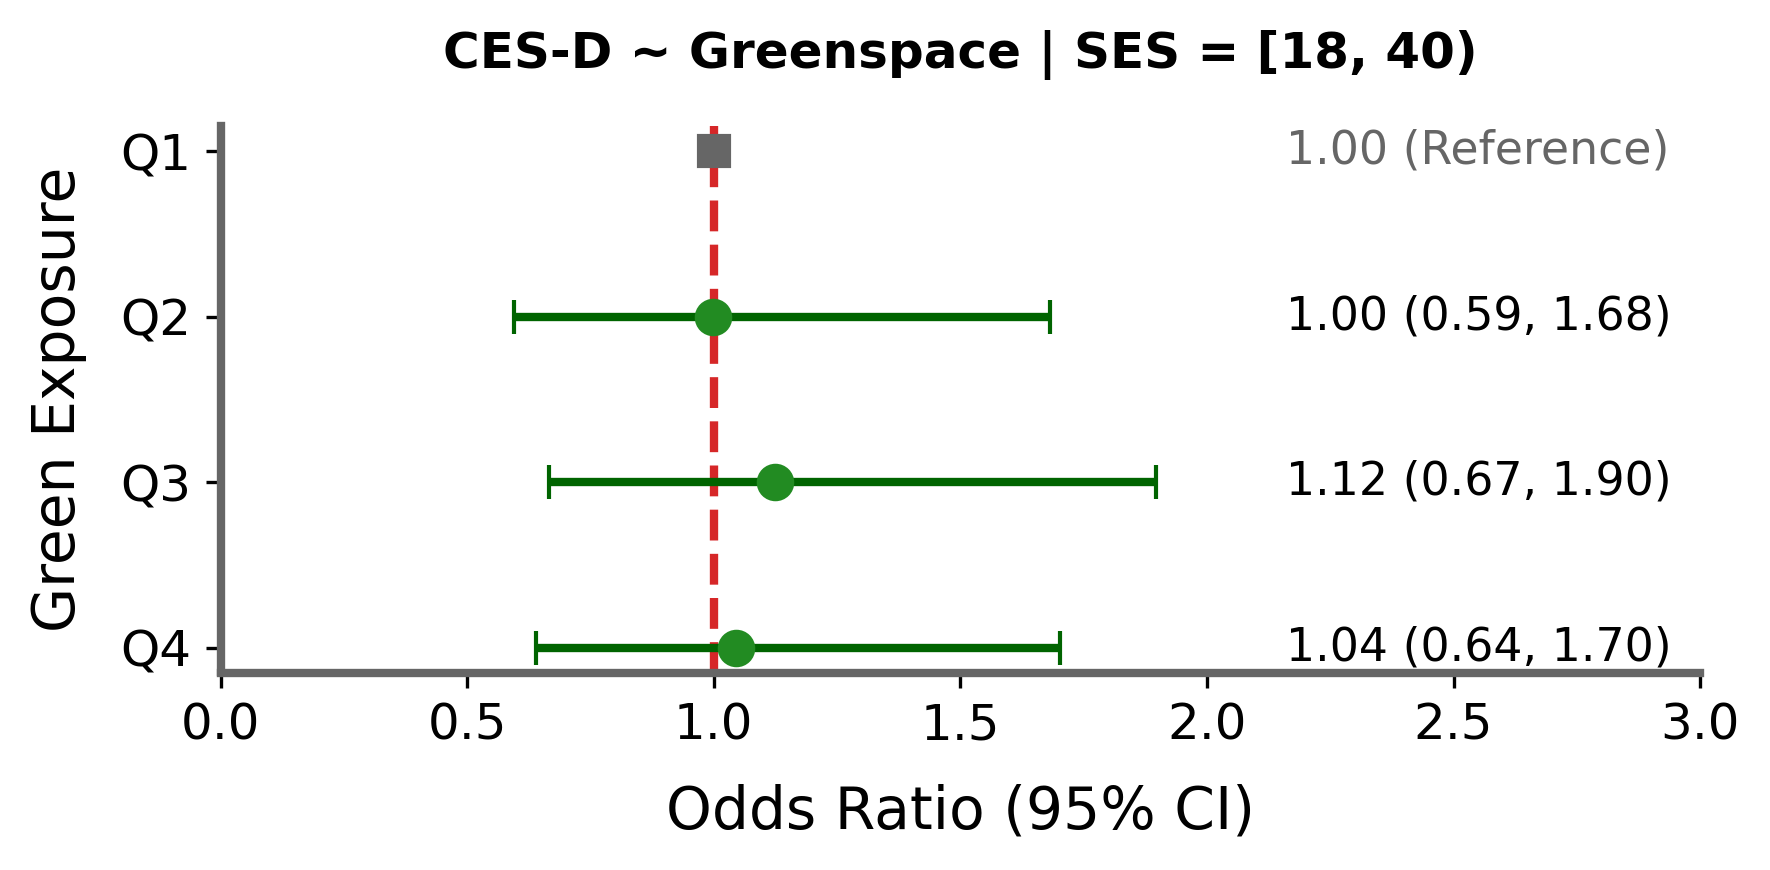

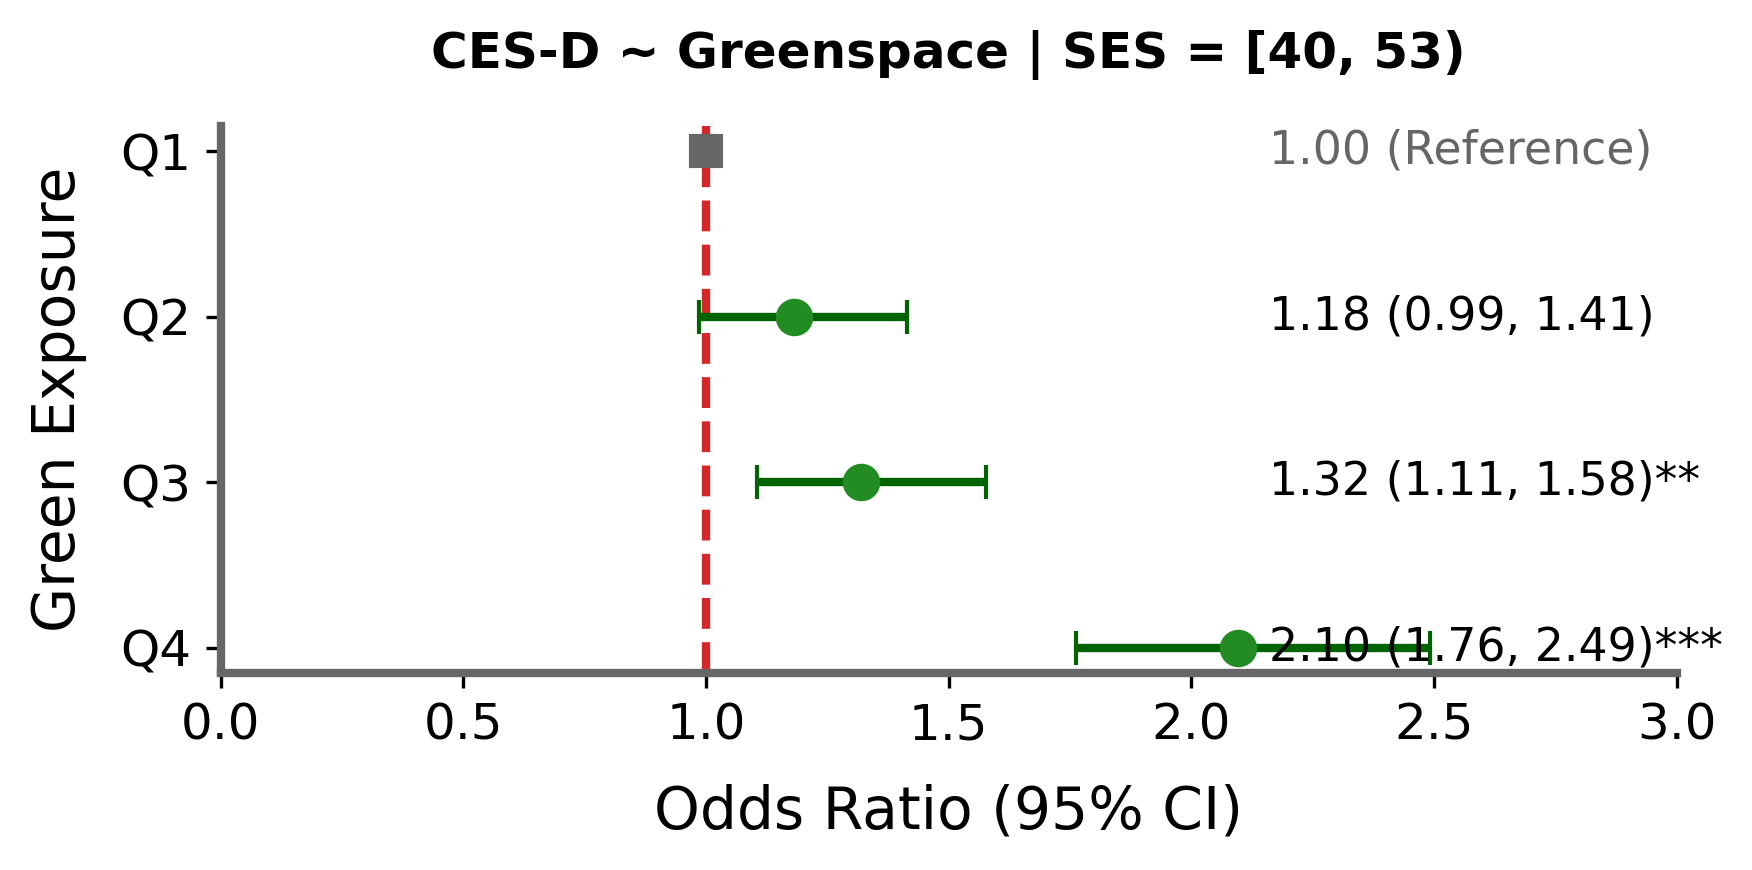

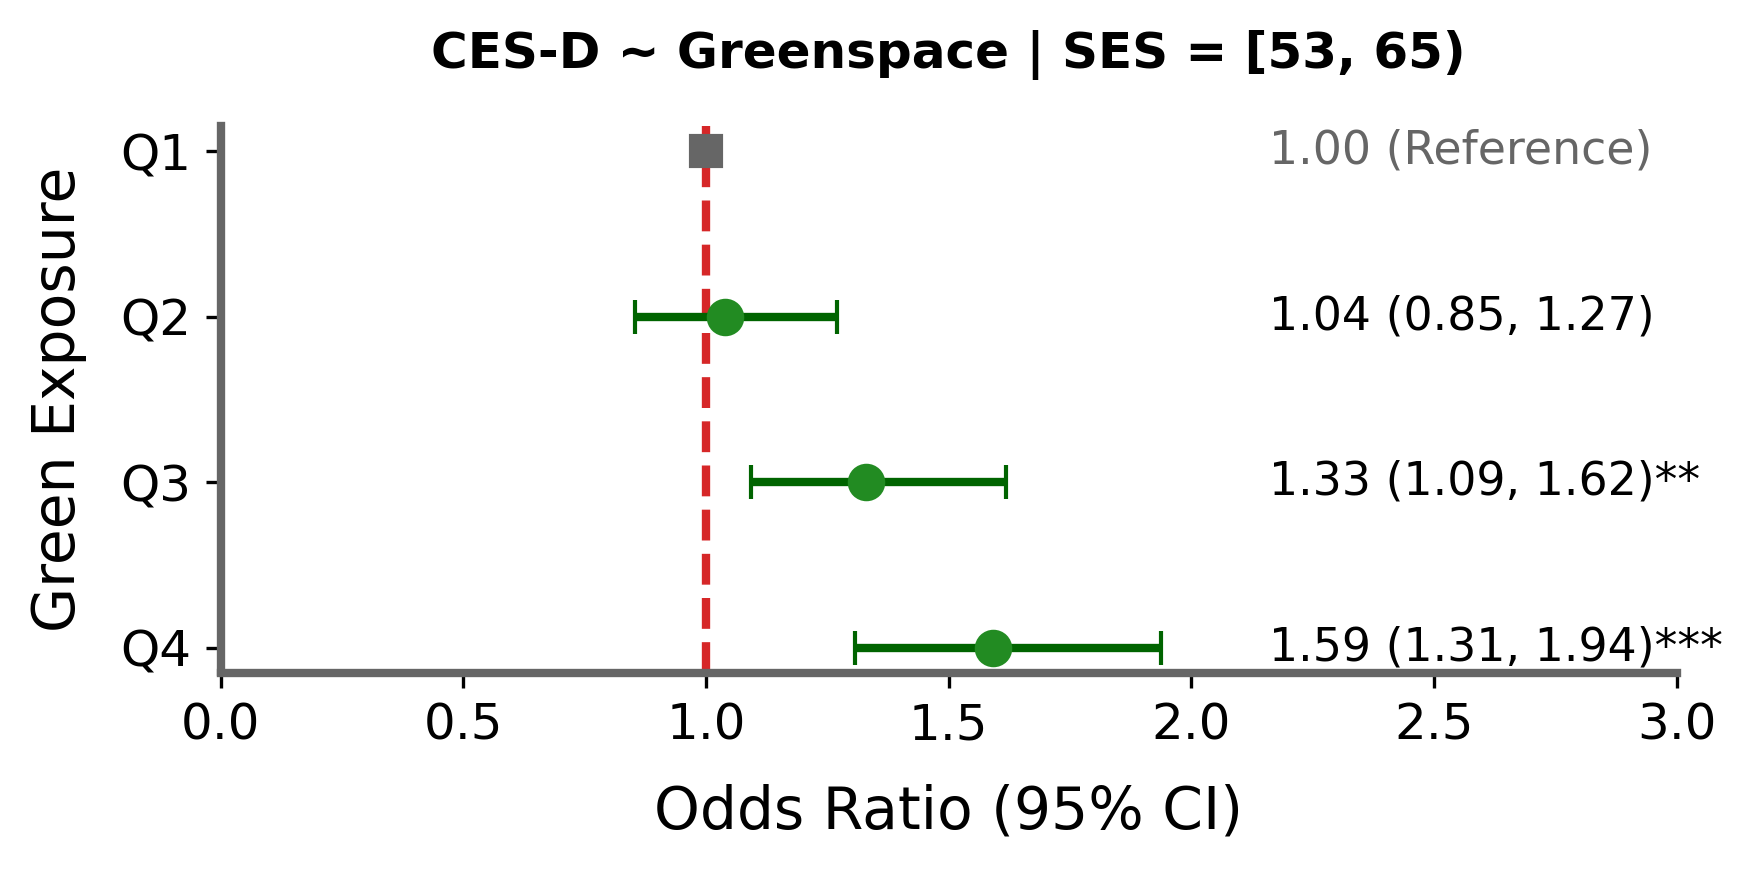

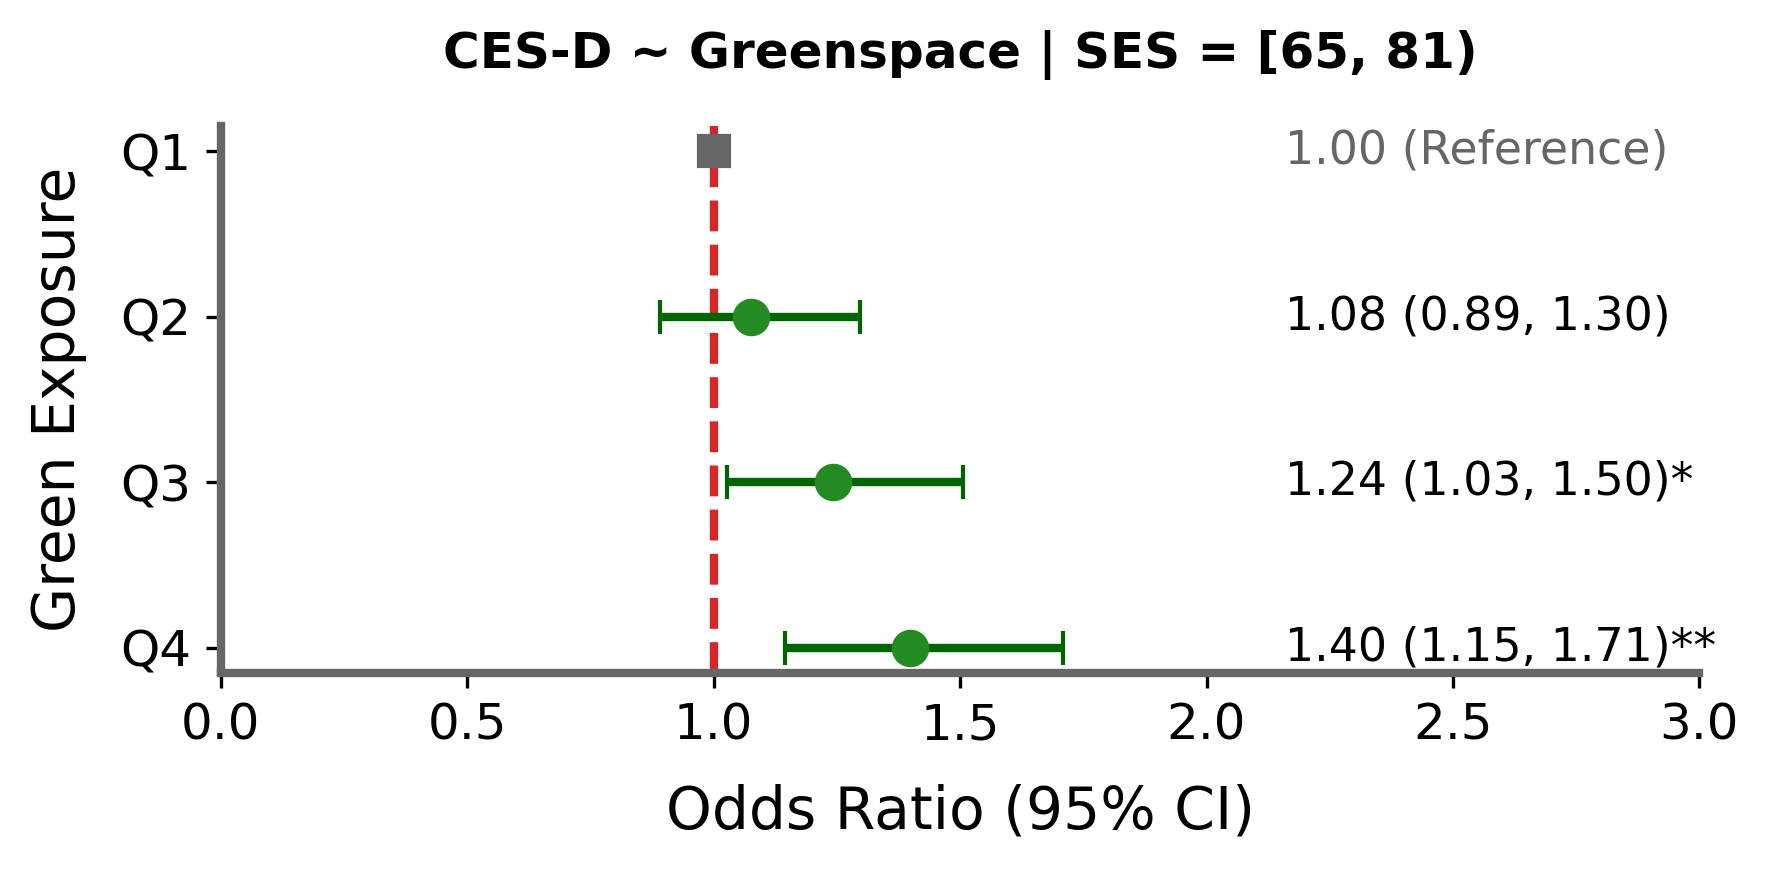

In [59]:
# Forest plot per stratum
for ses, res in strata_results.items():
    ordinal.plot_forest(
        res["or_table"],
        title = f"CES-D ~ Greenspace | SES = {ses}",
        predictor_type = "categorical"
    )

# Interaction Ordinal Model – Experiments

## SES-moderator: Mental Scores across NDVI

In [102]:
data = data_complete.copy()

inter_df, inter_store = experiment.run_interaction_grid(
    data                  = data,
    outcomes              = cols.mental_ordinal,
    predictors            = cols.ndvi,
    moderator             = "Socioeconomic Status (Tiers)",
    moderator_type        = "categorical",
#    moderator_reference   = 1.0,
    model_type            = "ordinal",
    predictor_type        = "continuous",
    scale_predictor       = 0.1,
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Sex", "Age"],
)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

  [1/12] CES-D Ordinal × NDVI (100m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9117 | 0/2 interaction terms p < 0.05
  [2/12] CES-D Ordinal × NDVI (200m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9117 | 0/2 interaction terms p < 0.05
  [3/12] CES-D Ordinal × NDVI (500m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9117 | 0/2 interaction terms p < 0.05
  [4/12] CES-D Ordinal × NDVI (1000m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9117 | 0/2 interaction terms p < 0.05
  [5/12] GAD-7 Ordinal × NDVI (100m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9278 | 0/2 interaction terms p < 0.05
  [6/12] GAD-7 Ordinal × NDVI (200m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9278 | 0/2 interaction terms p < 0.05
  [7/12] GAD-7 Ordinal × NDVI (500m Buffer)  [× Socioeconomic Status (Tiers), ordinal]


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant


## Save Interaction Model results to `ordinal_results` in `pkl` and `csv`

In [ ]:
#out_path = f"outputs/ordinal/interaction_ses/mental_ordinal/ndvi/adjusted/ordinal_results"
##experiment.save_results(inter_df, inter_store, path=out_path)

## SES-moderator: Mental Scores across Green Space Quartiles

In [107]:
data = data_complete.copy()

inter_df, inter_store = experiment.run_interaction_grid(
    data                  = data,
    outcomes              = cols.mental_ordinal,
    predictors            = cols.greenspace_quartiles,
    moderator             = "Socioeconomic Status (Tiers)",
    moderator_type        = "categorical",
#    moderator_reference   = 1.0,
    model_type            = "ordinal",
    predictor_type        = "categorical",
    reference_category    = "1.0",
    label_mapping         = {"1.0": "Q1", "2.0": "Q2", "3.0": "Q3", "4.0": "Q4"},
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Sex", "Age"],
)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

  [1/12] CES-D Ordinal × Green Space Quartile (100m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9079 | 0/6 interaction terms p < 0.05
  [2/12] CES-D Ordinal × Green Space Quartile (200m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9079 | 0/6 interaction terms p < 0.05
  [3/12] CES-D Ordinal × Green Space Quartile (500m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9079 | 1/6 interaction terms p < 0.05
  [4/12] CES-D Ordinal × Green Space Quartile (1000m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9079 | 0/6 interaction terms p < 0.05
  [5/12] GAD-7 Ordinal × Green Space Quartile (100m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9238 | 0/6 interaction terms p < 0.05
  [6/12] GAD-7 Ordinal × Green Space Quartile (200m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9238 | 0/6 interaction terms 

,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant
14,CES-D Ordinal,Green Space Quartile (500m Buffer),9079,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.796,"2.217 (1.233, 3.987)",0.008,121.7,"Sex, Age",True
38,GAD-7 Ordinal,Green Space Quartile (500m Buffer),9238,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.356,"1.427 (1.025, 1.987)",0.035,42.7,"Sex, Age",True


## Save Interaction Model results to `ordinal_results` in `pkl` and `csv`

In [ ]:
##out_path = f"outputs/ordinal/interaction_ses/mental_ordinal/quartiles/adjusted/ordinal_results"
##experiment.save_results(inter_df, inter_store, path=out_path)

# Analysis – SES-Moderator Ordinal Model

## Mental Scores vs. NDVI – unadjusted

In [84]:
out_path = f"outputs/ordinal/interaction_ses/mental_ordinal/ndvi/unadjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T20:21:32.182665


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant


## Mental Scores vs. NDVI – adjusted: Sex, Age

In [85]:
out_path = f"outputs/ordinal/interaction_ses/mental_ordinal/ndvi/adjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T20:22:02.919855


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [86]:
out_path = f"outputs/ordinal/interaction_ses/mental_ordinal/quartiles/unadjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T20:28:56.389490


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant
14,CES-D Ordinal,Green Space Quartile (500m Buffer),9079,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.816,"2.262 (1.264, 4.050)",0.006,126.2,unadjusted,True
38,GAD-7 Ordinal,Green Space Quartile (500m Buffer),9238,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.361,"1.434 (1.033, 1.991)",0.031,43.4,unadjusted,True
46,GAD-7 Ordinal,Green Space Quartile (1000m Buffer),9238,Socioeconomic Status (Tiers),3.0,Q1,Q3,0.406,"1.501 (1.004, 2.243)",0.048,50.1,unadjusted,True


## Mental Scores vs. Land-use-based Quartiles – adjusted: Sex, Age

In [87]:
out_path = f"outputs/ordinal/interaction_ses/mental_ordinal/quartiles/adjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T20:30:01.985308


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant
14,CES-D Ordinal,Green Space Quartile (500m Buffer),9079,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.796,"2.217 (1.233, 3.987)",0.008,121.7,"Sex, Age",True
38,GAD-7 Ordinal,Green Space Quartile (500m Buffer),9238,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.356,"1.427 (1.025, 1.987)",0.035,42.7,"Sex, Age",True


# Analysis – Age-Moderator Ordinal Model

## Mental Scores vs. NDVI – unadjusted

In [88]:
out_path = f"outputs/ordinal/interaction_age/mental_ordinal/ndvi/unadjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T20:18:06.207351


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant
7,CES-D Ordinal,NDVI (500m Buffer),9142,Age_group,"[53, 65)",0.1,-0.572,"0.564 (0.343, 0.928)",0.024,43.6,unadjusted,True


## Mental Scores vs. NDVI – adjusted: Sex, SES

In [89]:
out_path = f"outputs/ordinal/interaction_age/mental_ordinal/ndvi/adjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T20:18:54.933596


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant
7,CES-D Ordinal,NDVI (500m Buffer),9117,Age_group,"[53, 65)",0.1,-0.566,"0.568 (0.336, 0.960)",0.035,43.2,"Sex, Socioeconomic Status (Tiers)",True


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [90]:
out_path = f"outputs/ordinal/interaction_age/mental_ordinal/quartiles/unadjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T20:23:53.607370


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant
11,CES-D Ordinal,Green Space Quartile (200m Buffer),9104,Age_group,"[40, 53)",Q1,Q4,-1.391,"0.249 (0.098, 0.634)",0.004,75.1,unadjusted,True
14,CES-D Ordinal,Green Space Quartile (200m Buffer),9104,Age_group,"[53, 65)",Q1,Q4,-1.574,"0.207 (0.079, 0.542)",0.001,79.3,unadjusted,True
17,CES-D Ordinal,Green Space Quartile (200m Buffer),9104,Age_group,"[65, 81)",Q1,Q4,-1.211,"0.298 (0.110, 0.807)",0.017,70.2,unadjusted,True
20,CES-D Ordinal,Green Space Quartile (500m Buffer),9104,Age_group,"[40, 53)",Q1,Q4,-1.158,"0.314 (0.111, 0.886)",0.029,68.6,unadjusted,True
50,GAD-7 Ordinal,Green Space Quartile (200m Buffer),9264,Age_group,"[53, 65)",Q1,Q4,-0.711,"0.491 (0.259, 0.933)",0.030,50.9,unadjusted,True
92,SWLS Ordinal,Green Space Quartile (500m Buffer),9283,Age_group,"[40, 53)",Q1,Q4,0.710,"2.035 (1.197, 3.459)",0.009,103.5,unadjusted,True


## Mental Scores vs. Land-use-based Quartiles – adjusted: Sex, SES

In [91]:
out_path = f"outputs/ordinal/interaction_age/mental_ordinal/quartiles/adjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T20:25:29.461253


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant
1,CES-D Ordinal,Green Space Quartile (100m Buffer),9079,Age_group,"[40, 53)",Q1,Q3,-1.195,"0.303 (0.099, 0.923)",0.036,69.7,"Sex, Socioeconomic Status (Tiers)",True
4,CES-D Ordinal,Green Space Quartile (100m Buffer),9079,Age_group,"[53, 65)",Q1,Q3,-1.226,"0.294 (0.095, 0.907)",0.033,70.6,"Sex, Socioeconomic Status (Tiers)",True
11,CES-D Ordinal,Green Space Quartile (200m Buffer),9079,Age_group,"[40, 53)",Q1,Q4,-1.403,"0.246 (0.092, 0.659)",0.005,75.4,"Sex, Socioeconomic Status (Tiers)",True
14,CES-D Ordinal,Green Space Quartile (200m Buffer),9079,Age_group,"[53, 65)",Q1,Q4,-1.568,"0.208 (0.076, 0.574)",0.002,79.2,"Sex, Socioeconomic Status (Tiers)",True
17,CES-D Ordinal,Green Space Quartile (200m Buffer),9079,Age_group,"[65, 81)",Q1,Q4,-1.136,"0.321 (0.113, 0.915)",0.034,67.9,"Sex, Socioeconomic Status (Tiers)",True
20,CES-D Ordinal,Green Space Quartile (500m Buffer),9079,Age_group,"[40, 53)",Q1,Q4,-1.234,"0.291 (0.100, 0.849)",0.024,70.9,"Sex, Socioeconomic Status (Tiers)",True
50,GAD-7 Ordinal,Green Space Quartile (200m Buffer),9238,Age_group,"[53, 65)",Q1,Q4,-0.709,"0.492 (0.255, 0.951)",0.035,50.8,"Sex, Socioeconomic Status (Tiers)",True
80,SWLS Ordinal,Green Space Quartile (100m Buffer),9257,Age_group,"[65, 81)",Q1,Q4,-0.616,"0.540 (0.310, 0.939)",0.029,46.0,"Sex, Socioeconomic Status (Tiers)",True
92,SWLS Ordinal,Green Space Quartile (500m Buffer),9257,Age_group,"[40, 53)",Q1,Q4,0.635,"1.888 (1.104, 3.228)",0.020,88.8,"Sex, Socioeconomic Status (Tiers)",True


# Analysis – Sex-Moderator Ordinal Model

## Mental Scores vs. NDVI – unadjusted

In [92]:
out_path = f"outputs/ordinal/interaction_sex/mental_ordinal/ndvi/unadjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T20:19:39.455277


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant


## Mental Scores vs. NDVI – adjusted: Age, SES

In [93]:
out_path = f"outputs/ordinal/interaction_sex/mental_ordinal/ndvi/adjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T20:20:03.855732


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [94]:
out_path = f"outputs/ordinal/interaction_sex/mental_ordinal/quartiles/unadjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T20:26:30.545583


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant


## Mental Scores vs. Land-use-based Quartiles – adjusted: Age, SES

In [95]:
out_path = f"outputs/ordinal/interaction_sex/mental_ordinal/quartiles/adjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T20:27:13.654573


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant


# Interaction Ordinal Model – Single Mental Health Variable

In [96]:
data = data_complete.copy()

result, meta, interaction_table = ordinal.fit_interaction(
    data                = data,
    outcome             = "SWLS Ordinal", #"CES-D Ordinal",
    predictor           = "NDVI (500m Buffer)", #"Green Space Quartile (500m Buffer)",
    moderator           = "Socioeconomic Status (Tiers)",
    moderator_type      = "categorical",
#    moderator_reference = 1.0, # low SES as reference
    predictor_type      = "continuous",
    scale_predictor     = 0.1,
#    reference_category  = "1.0",
#    label_mapping       = {"1.0": "Q1", "2.0": "Q2", "3.0": "Q3", "4.0": "Q4"},
    #covariates          = ["Age", "Sex"],
)

display(interaction_table)

  Interaction fitted | n = 9297 | 0/2 interaction terms p < 0.05


,outcome,predictor,predictor_type,moderator,scale_predictor,reference_level,level,moderator_level,beta,OR,CI_lower,CI_upper,OR_95CI,p_value,p_value_fmt,pct_change_odds,covariates,significant
0,SWLS Ordinal,NDVI (500m Buffer),continuous,Socioeconomic Status (Tiers),0.1,None,NDVI (500m Buffer),2.0,0.070,1.073,0.945,1.218,"1.073 (0.945, 1.218)",0.278408,0.278,7.3,unadjusted,False
1,SWLS Ordinal,NDVI (500m Buffer),continuous,Socioeconomic Status (Tiers),0.1,None,NDVI (500m Buffer),3.0,-0.056,0.946,0.815,1.098,"0.946 (0.815, 1.098)",0.463688,0.464,5.4,unadjusted,False
